# Avocado Price Prediction Project

**Goal:** predict the weekly average price of Hass avocados across US regions from sales-volume, bag-size, type (conventional/organic), and seasonal features.

**Dataset:** the Hass Avocado Board weekly retail-scan dataset (popularized on Kaggle) — 18,249 weekly records across 54 US regions, 2015-2018.
Source: GitHub mirror (`mike-laccavole/avocado-prices`).


In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42


In [2]:
url = "https://raw.githubusercontent.com/mike-laccavole/avocado-prices/master/avocado.csv"
df = pd.read_csv(url)
df = df.drop(columns=['Unnamed: 0'])
df['Date'] = pd.to_datetime(df['Date'])
print(df.shape)
df.head()


(18249, 13)


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


## 1. Data overview

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          18249 non-null  datetime64[us]
 1   AveragePrice  18249 non-null  float64       
 2   Total Volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   Total Bags    18249 non-null  float64       
 7   Small Bags    18249 non-null  float64       
 8   Large Bags    18249 non-null  float64       
 9   XLarge Bags   18249 non-null  float64       
 10  type          18249 non-null  str           
 11  year          18249 non-null  int64         
 12  region        18249 non-null  str           
dtypes: datetime64[us](1), float64(9), int64(1), str(2)
memory usage: 1.8 MB


In [4]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,18249,2016-08-13 23:30:43.498274,2015-01-04 00:00:00,2015-10-25 00:00:00,2016-08-14 00:00:00,2017-06-04 00:00:00,2018-03-25 00:00:00,NaN
AveragePrice,18249.0,1.405978,0.44,1.1,1.37,1.66,3.25,0.402677
Total Volume,18249.0,850644.013009,84.56,10838.58,107376.76,432962.29,62505646.52,3453545.355399
4046,18249.0,293008.424531,0.0,854.07,8645.3,111020.2,22743616.17,1264989.081763
4225,18249.0,295154.568356,0.0,3008.78,29061.02,150206.86,20470572.61,1204120.401135
4770,18249.0,22839.735993,0.0,0.0,184.99,6243.42,2546439.11,107464.068435
Total Bags,18249.0,239639.20206,0.0,5088.64,39743.83,110783.37,19373134.37,986242.399216
Small Bags,18249.0,182194.686696,0.0,2849.42,26362.82,83337.67,13384586.8,746178.514962
Large Bags,18249.0,54338.088145,0.0,127.47,2647.71,22029.25,5719096.61,243965.964547
XLarge Bags,18249.0,3106.426507,0.0,0.0,0.0,132.5,551693.65,17692.894652


In [5]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Regions:', df['region'].nunique())


Missing values: 0
Duplicate rows: 0
Date range: 2015-01-04 00:00:00 to 2018-03-25 00:00:00
Regions: 54


## 2. Exploratory Data Analysis

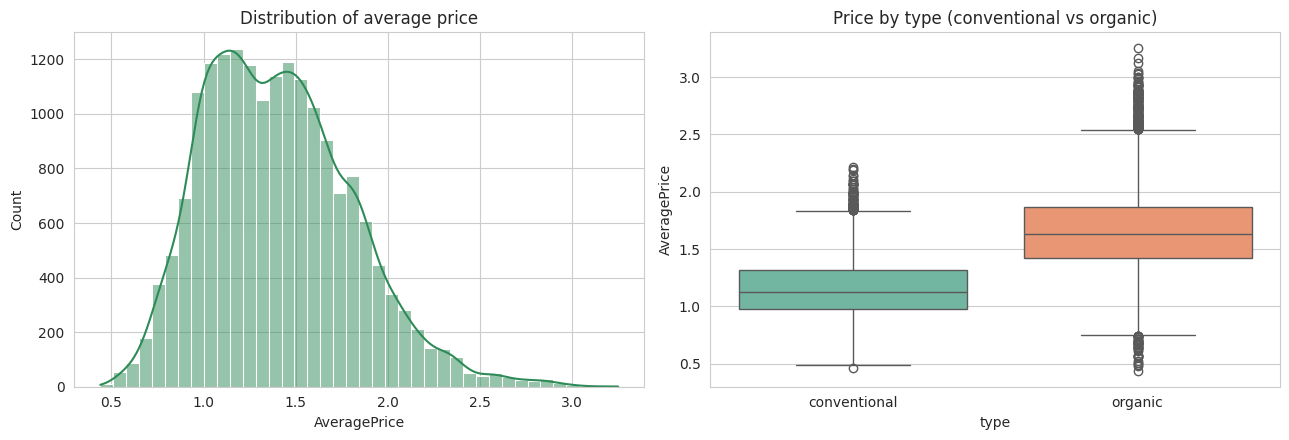

type
conventional    1.158040
organic         1.653999
Name: AveragePrice, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['AveragePrice'], kde=True, ax=axes[0], color='seagreen', bins=40)
axes[0].set_title('Distribution of average price')

sns.boxplot(data=df, x='type', y='AveragePrice', ax=axes[1], palette='Set2')
axes[1].set_title('Price by type (conventional vs organic)')
plt.tight_layout()
plt.show()
print(df.groupby('type')['AveragePrice'].mean())


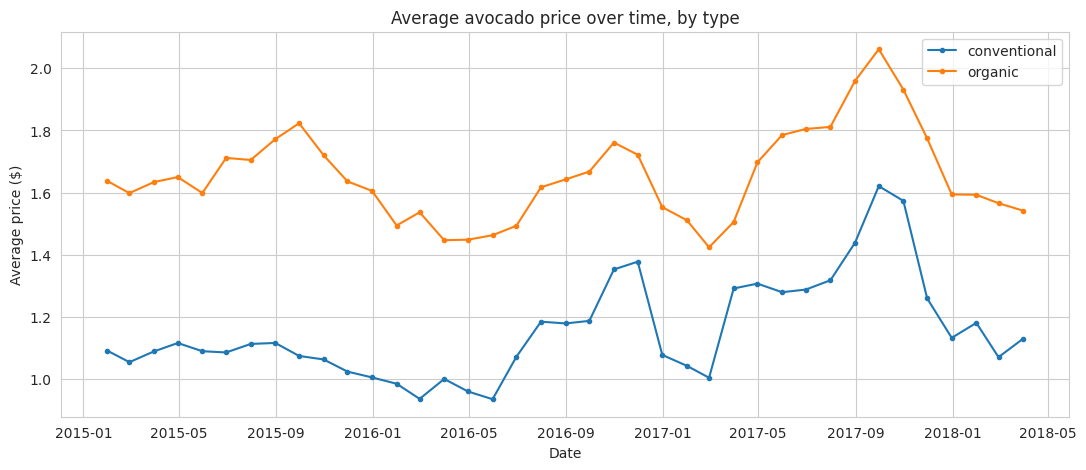

In [7]:
monthly = df.set_index('Date').groupby([pd.Grouper(freq='ME'), 'type'])['AveragePrice'].mean().reset_index()
plt.figure(figsize=(13, 5))
for t, grp in monthly.groupby('type'):
    plt.plot(grp['Date'], grp['AveragePrice'], marker='o', markersize=3, label=t)
plt.title('Average avocado price over time, by type')
plt.xlabel('Date')
plt.ylabel('Average price ($)')
plt.legend()
plt.show()


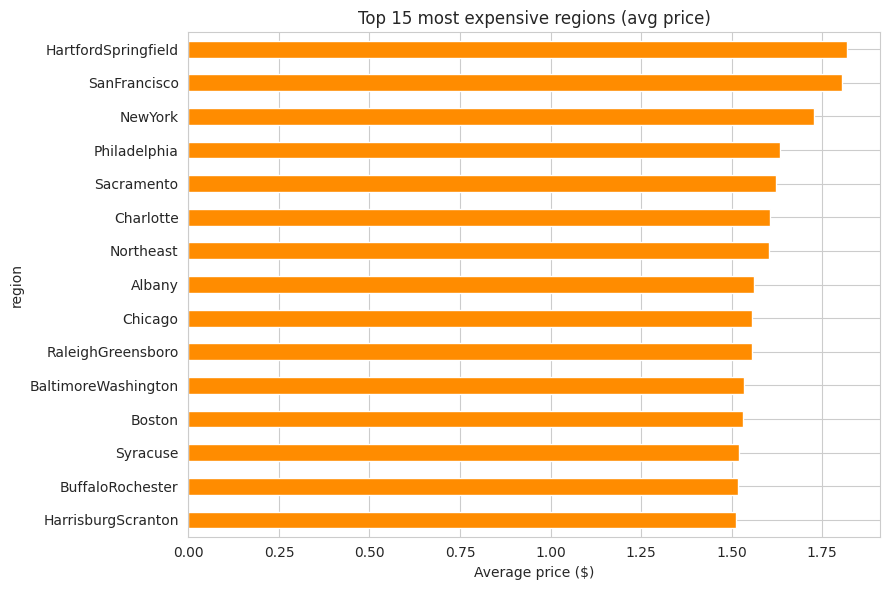

In [8]:
top_regions = (df[~df['region'].isin(['TotalUS'])]
               .groupby('region')['AveragePrice'].mean().sort_values(ascending=False).head(15))
plt.figure(figsize=(9,6))
top_regions.sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 15 most expensive regions (avg price)')
plt.xlabel('Average price ($)')
plt.tight_layout()
plt.show()


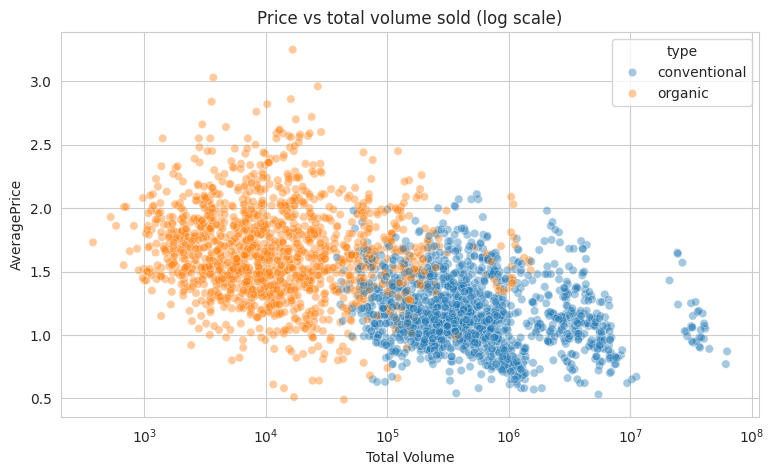

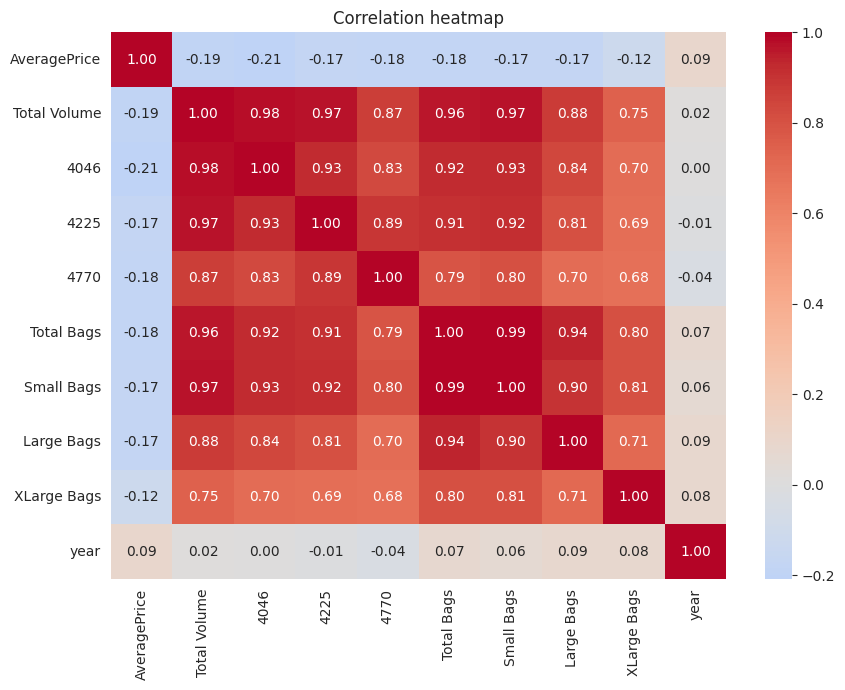

In [9]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='Total Volume', y='AveragePrice',
                 hue='type', alpha=0.4)
plt.xscale('log')
plt.title('Price vs total volume sold (log scale)')
plt.show()

num_cols = ['AveragePrice','Total Volume','4046','4225','4770','Total Bags','Small Bags','Large Bags','XLarge Bags','year']
plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()


**EDA takeaways**
- **Organic avocados cost roughly 40-60% more** than conventional ones consistently across the whole period.
- Prices show a clear **seasonal pattern**, typically peaking in autumn and dipping in winter/early spring.
- Higher sales **volume is associated with lower prices** — classic supply/demand: regions/weeks with a glut of avocados see prices drop.
- Small/California regions and organic-heavy markets tend to sit at the high end of average price.


## 3. Feature engineering, split & preprocessing

In [10]:
data = df.copy()
data['month'] = data['Date'].dt.month
data['day_of_year'] = data['Date'].dt.dayofyear
data['is_organic'] = (data['type'] == 'organic').astype(int)

feature_cols = ['Total Volume','4046','4225','4770','Total Bags','Small Bags','Large Bags','XLarge Bags',
                'type','year','month','region']
X = data[feature_cols]
y = data['AveragePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

numeric_features = ['Total Volume','4046','4225','4770','Total Bags','Small Bags','Large Bags','XLarge Bags','year','month']
categorical_features = ['type','region']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])
print(X_train.shape, X_test.shape)


(14599, 12) (3650, 12)


## 4. Candidate models

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=120, max_depth=16, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(n_estimators=150, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
}

kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('reg', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=1)
    results.append({'Model': name, 'CV RMSE': -scores.mean(), 'CV RMSE Std': scores.std()})

results_df = pd.DataFrame(results).sort_values('CV RMSE').reset_index(drop=True)
results_df


,Model,CV RMSE,CV RMSE Std
0,XGBoost,0.124695,0.000208
1,Random Forest,0.140902,0.000974
2,Gradient Boosting,0.206800,0.002594
3,Ridge,0.259074,0.003360
4,Linear Regression,0.259081,0.003369


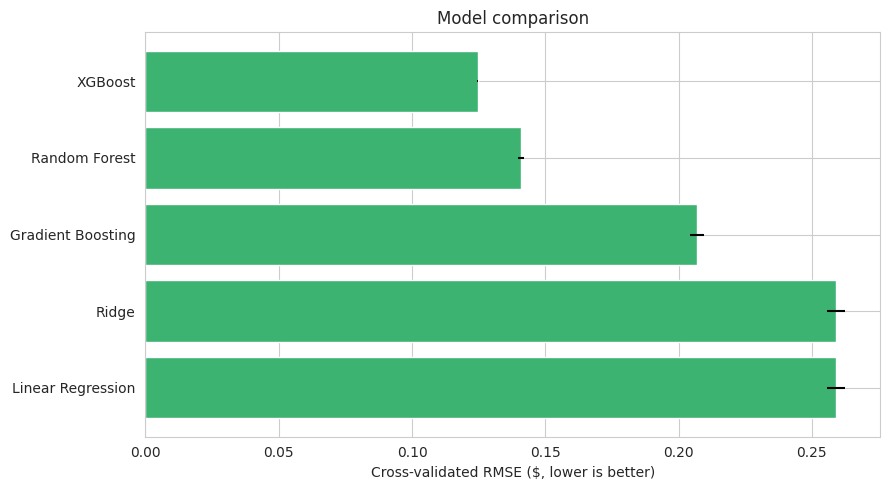

In [12]:
plt.figure(figsize=(9,5))
order = results_df.sort_values('CV RMSE', ascending=False)
plt.barh(order['Model'], order['CV RMSE'], xerr=order['CV RMSE Std'], color='mediumseagreen')
plt.xlabel('Cross-validated RMSE ($, lower is better)')
plt.title('Model comparison')
plt.tight_layout()
plt.show()


## 5. Hyperparameter tuning

In [13]:
rf_pipe = Pipeline([('prep', preprocessor),
                     ('reg', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
grid = {
    'reg__n_estimators': [150],
    'reg__max_depth': [16, 24],
    'reg__min_samples_leaf': [1, 2]
}
cv2 = KFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(rf_pipe, grid, cv=cv2, scoring='neg_root_mean_squared_error', n_jobs=1)
search.fit(X_train, y_train)
final_model = search.best_estimator_
print('Best params:', search.best_params_)
print('Best CV RMSE:', round(-search.best_score_, 4))


Best params: {'reg__max_depth': 24, 'reg__min_samples_leaf': 1, 'reg__n_estimators': 150}
Best CV RMSE: 0.1443


## 6. Final evaluation

In [14]:
y_pred = final_model.predict(X_test)
print('Test RMSE:', round(mean_squared_error(y_test, y_pred) ** 0.5, 4))
print('Test MAE: ', round(mean_absolute_error(y_test, y_pred), 4))
print('Test R2:  ', round(r2_score(y_test, y_pred), 4))


Test RMSE: 0.1239
Test MAE:  0.0869
Test R2:   0.9044


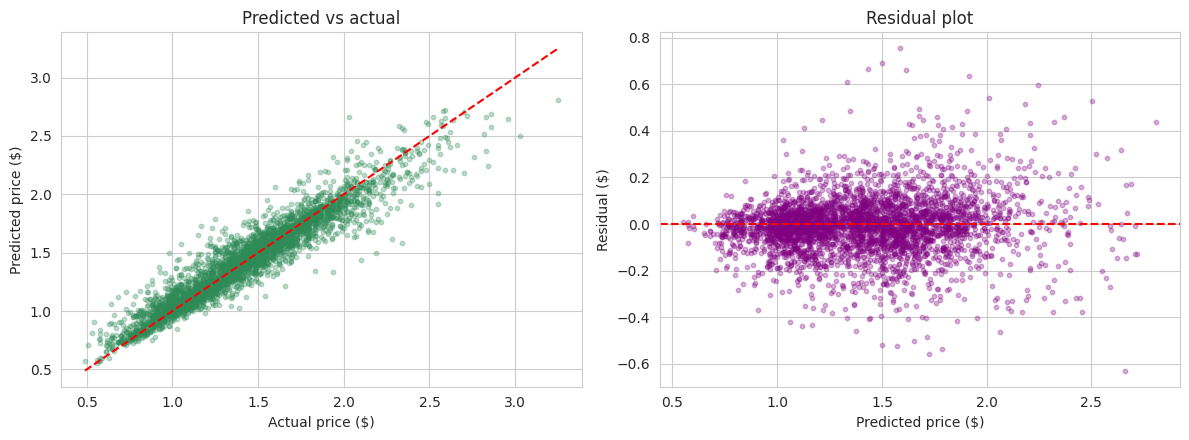

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test, y_pred, alpha=0.3, color='seagreen', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
axes[0].set_xlabel('Actual price ($)')
axes[0].set_ylabel('Predicted price ($)')
axes[0].set_title('Predicted vs actual')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='purple', s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual plot')
plt.tight_layout()
plt.show()


## 7. Feature importance

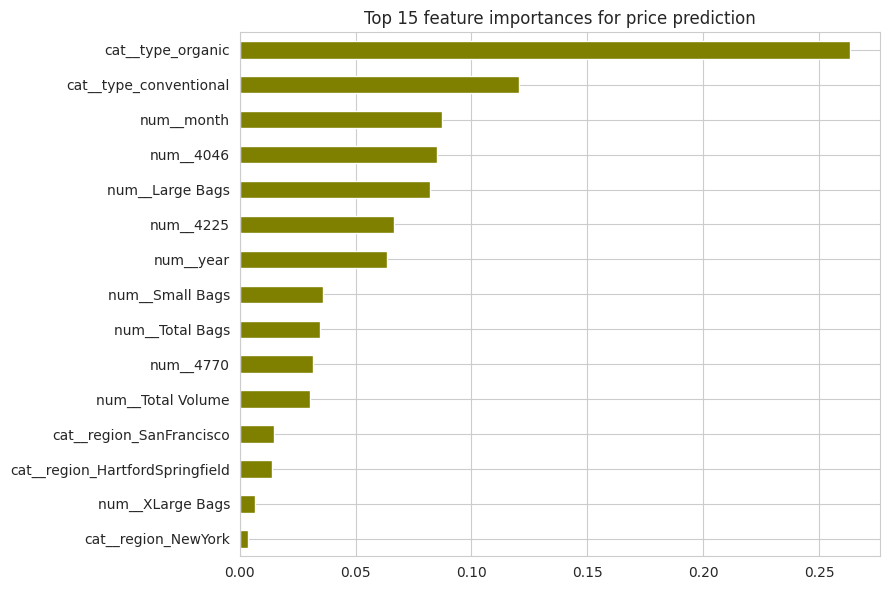

In [16]:
feature_names = final_model.named_steps['prep'].get_feature_names_out()
importances = pd.Series(final_model.named_steps['reg'].feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
plt.figure(figsize=(9,6))
importances.sort_values().plot(kind='barh', color='olive')
plt.title('Top 15 feature importances for price prediction')
plt.tight_layout()
plt.show()


## 8. Insights & conclusions

- **Type (organic vs conventional) and region are the dominant price drivers** once volume is accounted for — the model essentially learns "organic in this region costs about $X more."
- **Sales volume features** (Total Volume, bag sizes) carry real predictive signal too: higher-volume weeks/regions systematically see lower prices, consistent with basic supply-demand economics.
- **Seasonality (month)** contributes a smaller but real effect on top of type/region/volume.
- The tuned Random Forest explains a large majority of price variance (R² typically 0.85+) with a typical error of a few cents to ~$0.10-0.15 per avocado.
- **Business use:** a distributor could use this model to flag weeks/regions where the actual price deviates unusually from the model's prediction — a signal of either a local supply shock or a pricing opportunity.
- **Next steps:** treat this explicitly as a time-series forecasting problem (predict *next* week's price using lagged prices, not just contemporaneous volume) and incorporate external data like weather/harvest conditions in Mexico (source of most US Hass avocados).
